# Conditioned-MIDI bGPT (Translator) — model validation

Loads the `CondMidiPatchy` dataset and the `MidiBgptTrans` / `MidiBgptTransLoss` model.
The two modalities are **two independent weight towers**: a `lyl_encoder` (a `PatchLevelDecoder`,
same arch as `LilyletNotaGen.patch_level_decoder`, so it can be initialised from a pretrained
NotaGen and optionally frozen) encoding the lilylet score into memory, and a separate midi
decoder doing causal windowed self-attention + cross-attention into that memory.

This notebook: inspects a batch, builds the model, checks the two derived decoder masks,
runs a forward pass, verifies the freeze / pretrained-load options, then overfits one batch.

Config: `configs/midi-measurewise-trans.yaml` · Data: `~/data/lilylet/midi-measurewise/test20260629/cond-midi.lmmw.pt`

In [1]:
from pathlib import Path
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel

DATA_DIR = str(Path.home() / 'data')
CONFIG = str(REPO_ROOT / 'configs' / 'midi-measurewise-trans.yaml')
print('repo:', REPO_ROOT)
print('data dir:', DATA_DIR)

repo: /home/camus/work/deep-starry
data dir: /home/camus/data


## 1. Load dataset + a small CPU model, inspect one batch

The corpus is NOT cropped (`patch_length: 0`), so we shrink the model (not the data) to keep
this validation quick on CPU. A 2-sample batch of differing length exercises padding.

In [2]:
config = Configuration.createOrLoad(CONFIG, volatile=True)
config['data.batch_size'] = 2
config['trainer.device'] = 'cpu'
# smaller model keeps this validation quick on CPU (data stays uncropped)
config['model.args.lyl_hidden_size'] = 64
config['model.args.lyl_patch_num_layers'] = 2
config['model.args.lyl_n_head'] = 4
config['model.args.lyl_num_key_value_heads'] = 4
config['model.args.lyl_intermediate_size'] = 128
config['model.args.d_model'] = 96
config['model.args.n_dec_layer'] = 2
config['model.args.token_num_layers'] = 2
config['model.args.n_head'] = 4
config['model.args.d_inner'] = 192

train, val = loadDataset(config, data_dir=DATA_DIR, device='cpu')
print('train items:', len(train.dataset), 'val items:', len(val.dataset))

batch = next(iter(train))
print('batch keys:', list(batch.keys()))
for k in ['input_patches', 'input_masks', 'input_targets', 'input_positions', 'attn_mask', 'modality', 'lyl_counts']:
    print(f'  {k:16} {tuple(batch[k].shape)} {batch[k].dtype}')
print('real patches per item :', batch['input_masks'].sum(dim=1).tolist())
print('midi targets per item :', batch['input_targets'].sum(dim=1).tolist())
print('lyl_counts            :', batch['lyl_counts'].tolist())
print('targets only on midi  :', bool(((batch['input_targets'] == 1) & (batch['modality'] == 0)).sum() == 0))

train items: 205 val items: 10


batch keys: ['input_patches', 'input_masks', 'input_targets', 'input_positions', 'attn_mask', 'modality', 'lyl_counts']
  input_patches    (2, 3546, 16) torch.int64
  input_masks      (2, 3546) torch.int64
  input_targets    (2, 3546) torch.int64
  input_positions  (2, 3546) torch.int64
  attn_mask        (2, 1, 3546, 3546) torch.bool
  modality         (2, 3546) torch.int64
  lyl_counts       (2,) torch.int64
real patches per item : [2505, 3546]
midi targets per item : [2160, 3024]
lyl_counts            : [344, 521]
targets only on midi  : True


## 2. Build the model via the factory

In [3]:
deducer = loadModel(config['model'], imports=config['imports'])
model = loadModel(config['model'], postfix='Loss', imports=config['imports'])
print('deducer:', type(deducer).__name__, '| loss model:', type(model).__name__)

d = model.deducer
n_params = sum(p.numel() for p in d.parameters())
n_enc = sum(p.numel() for p in d.lyl_encoder.parameters())
print('MidiBgptTrans params: %.2fM (lyl_encoder %.2fM)' % (n_params / 2**20, n_enc / 2**20))
print('lyl_encoder: a', type(d.lyl_encoder).__name__, '(loadable from LilyletNotaGen.patch_level_decoder)')
print('midi decoder layers:', len(d.decoder))
print('token-level layers:', d.token_level_decoder.base.config.num_hidden_layers)
print('enc_proj (lyl_hidden -> d_model):', d.enc_proj is not None)
print('lyl/midi vocab:', d.lyl_vocab_size, '/', d.midi_vocab_size)

deducer: MidiBgptTrans | loss model: MidiBgptTransLoss
MidiBgptTrans params: 0.79M (lyl_encoder 0.33M)
lyl_encoder: a PatchLevelDecoder (loadable from LilyletNotaGen.patch_level_decoder)
midi decoder layers: 2
token-level layers: 2
enc_proj (lyl_hidden -> d_model): True
lyl/midi vocab: 256 / 41


## 3. The two derived decoder masks

`MidiBgptTrans._dec_masks` slices the feeder's joint mask into the midi decoder's two masks:
a **decoder-self** mask (midi→midi window, with a self-loop on non-midi rows for SDPA
finiteness) and a **cross** mask (midi→lilylet window, over the lyl-segment key positions
`0..max(lyl_counts)-1`). The lyl encoder itself attends bidirectionally over the score
(its own padding mask), so it has no derived block mask here.

In [4]:
m = model.deducer
Lmax = int(batch['lyl_counts'].max())
dec_self, cross = m._dec_masks(batch['attn_mask'], batch['modality'], batch['input_masks'], Lmax)
mod, msk = batch['modality'], batch['input_masks']
b = 0
checks = {
    'cross: key axis spans the lyl segment (Lmax)':          cross.shape[2] == Lmax,
    'cross: all attended keys are lilylet':                  bool((cross[b].any(0) <= (mod[b][:Lmax] == 0)).all()),
    'cross: all querying rows are midi':                     bool((cross[b].any(1) <= (mod[b] == 1)).all()),
    'dec_self: no future leak among midi (upper-tri empty)': not (dec_self[b] & (mod[b]==1).unsqueeze(1) & (mod[b]==1).unsqueeze(0)).triu(1).any().item(),
    'dec_self: every row non-empty (SDPA safety)':           bool((dec_self[b].sum(1) >= 1).all()),
}
for k, ok in checks.items():
    print(('  OK  ' if ok else ' FAIL ') + k)
assert all(checks.values())

  OK  cross: key axis spans the lyl segment (Lmax)
  OK  cross: all attended keys are lilylet
  OK  cross: all querying rows are midi
  OK  dec_self: no future leak among midi (upper-tri empty)
  OK  dec_self: every row non-empty (SDPA safety)


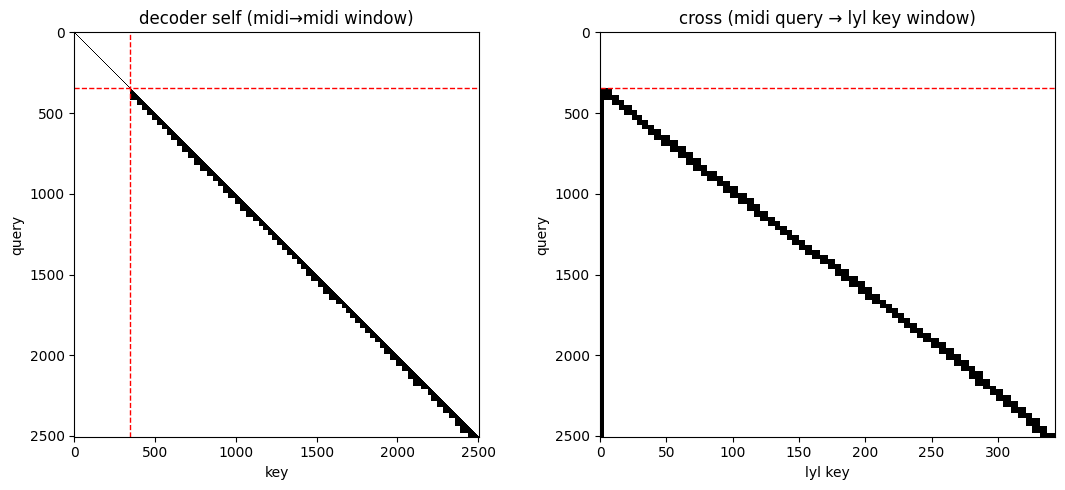

In [5]:
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt

L = int(batch['lyl_counts'][b]); T = int(msk[b].sum())
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(dec_self[b, :T, :T].numpy(), cmap='Greys', interpolation='nearest', aspect='equal')
ax[0].axvline(L - 0.5, color='r', ls='--', lw=1); ax[0].axhline(L - 0.5, color='r', ls='--', lw=1)
ax[0].set_title('decoder self (midi→midi window)'); ax[0].set_xlabel('key'); ax[0].set_ylabel('query')
ax[1].imshow(cross[b, :T, :L].numpy(), cmap='Greys', interpolation='nearest', aspect='auto')
ax[1].axhline(L - 0.5, color='r', ls='--', lw=1)
ax[1].set_title('cross (midi query → lyl key window)'); ax[1].set_xlabel('lyl key'); ax[1].set_ylabel('query')
plt.tight_layout(); plt.show()

## 4. Forward pass: loss, metrics, inspectRun

In [6]:
model.train()
loss, metric = model(batch)
print('loss:', loss.item())
print('metric:', metric)
assert loss.requires_grad and loss.dim() == 0 and torch.isfinite(loss)

model.eval()
with torch.no_grad():
    insp = model.inspectRun(batch)
print('inspect:', {k: (v if not torch.is_tensor(v) else tuple(v.shape)) for k, v in insp.items()})
assert insp['n_patches'] == sum(batch['input_targets'].sum(dim=1).tolist())

loss: 3.7873599529266357
metric: {'acc': 0.004820294212549925, 'err': 0.9951797057874501}


inspect: {'loss': 3.7882628440856934, 'acc': 0.004798080772161484, 'err': 0.9952019192278385, 'time_err': 0.9841219428926706, 'logits': (5184, 17, 41), 'target_patches': (5184, 16), 'n_patches': 5184}


## 5. Overfit one batch — loss should drop, acc should rise

In [7]:
model.train()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
history = []
for step in range(20):
    opt.zero_grad()
    loss, metric = model(batch)
    loss.backward()
    opt.step()
    history.append((loss.item(), metric['acc']))
    if step % 5 == 0 or step == 19:
        print(f'step {step:02d}  loss={loss.item():.4f}  acc={metric["acc"]:.4f}')

print('\nloss start -> end:', round(history[0][0], 4), '->', round(history[-1][0], 4))
print('acc  start -> end:', round(history[0][1], 4), '->', round(history[-1][1], 4))
assert history[-1][0] < history[0][0], 'loss did not decrease'

step 00  loss=3.7874  acc=0.0048


step 05  loss=2.6193  acc=0.5646


step 10  loss=2.1763  acc=0.5793


step 15  loss=1.7987  acc=0.6814


step 19  loss=1.5463  acc=0.6929

loss start -> end: 3.7874 -> 1.5463
acc  start -> end: 0.0048 -> 0.6929


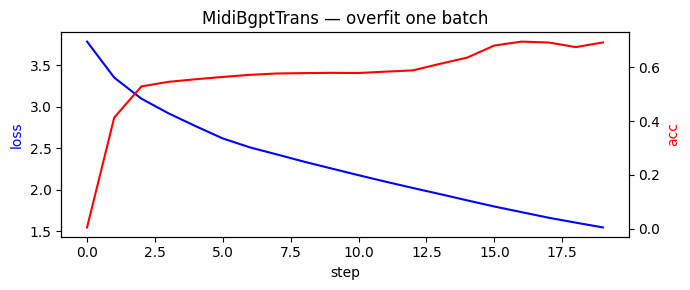

In [8]:
losses = [h[0] for h in history]
accs = [h[1] for h in history]
fig, ax1 = plt.subplots(figsize=(7, 3))
ax1.plot(losses, 'b-', label='loss'); ax1.set_ylabel('loss', color='b'); ax1.set_xlabel('step')
ax2 = ax1.twinx(); ax2.plot(accs, 'r-', label='acc'); ax2.set_ylabel('acc', color='r')
plt.title('MidiBgptTrans — overfit one batch'); plt.tight_layout(); plt.show()

## 6. Independent towers: pretrained load + freeze

The `lyl_encoder` is a `PatchLevelDecoder` with the same arch as `LilyletNotaGen.patch_level_decoder`,
so a pretrained NotaGen's patch tower loads into it with **0 missing / 0 unexpected** keys. With
`freeze_lyl_encoder=True` the encoder is detached from training: `requires_grad=False`, kept in
`eval()` even under `model.train()`, no grads, and excluded from `training_parameters()`.

In [9]:
from starry.lilylet.models.notagen import LilyletNotaGen

# (a) key alignment: a real NotaGen patch tower -> lyl_encoder, same arch as the small model here
nota = LilyletNotaGen(base_type='llama', token_vocab_size=256, patch_size=16, patch_length=1024,
    hidden_size=64, patch_num_layers=2, token_num_layers=2, n_head=4, num_key_value_heads=4, intermediate_size=128)
missing, unexpected = model.deducer.lyl_encoder.load_state_dict(nota.patch_level_decoder.state_dict(), strict=False)
print('pretrained load: missing=%d unexpected=%d' % (len(missing), len(unexpected)))
assert not missing and not unexpected

# (b) freeze: build a frozen variant via the factory and verify it is detached from training
config['model.args.freeze_lyl_encoder'] = True
frozen = loadModel(config['model'], postfix='Loss', imports=config['imports'])
frozen.train()  # frozen encoder must stay in eval
n_total = sum(1 for _ in frozen.parameters())
n_train = len([p for p in frozen.training_parameters() if isinstance(p, torch.Tensor) and p.requires_grad])
print('freeze: encoder all requires_grad False:', all(not p.requires_grad for p in frozen.deducer.lyl_encoder.parameters()))
print('freeze: encoder stays eval under train():', not frozen.deducer.lyl_encoder.training)
print('freeze: trainable tensors %d of %d total' % (n_train, n_total))

loss_f, _ = frozen(batch); loss_f.backward()
enc_grads = sum(1 for p in frozen.deducer.lyl_encoder.parameters() if p.grad is not None)
dec_grads = sum(1 for p in frozen.deducer.decoder.parameters() if p.grad is not None)
print('freeze: lyl_encoder grad tensors=%d (expect 0), decoder grad tensors=%d (expect >0)' % (enc_grads, dec_grads))
assert enc_grads == 0 and dec_grads > 0
config['model.args.freeze_lyl_encoder'] = False  # restore

pretrained load: missing=0 unexpected=0
freeze: encoder all requires_grad False: True
freeze: encoder stays eval under train(): True
freeze: trainable tensors 63 of 85 total


freeze: lyl_encoder grad tensors=0 (expect 0), decoder grad tensors=36 (expect >0)
